# Analisis de TAXI y Limosine NYC

## Datos del registro de viajes de TLC

Los registros de viajes en taxi amarillo y verde incluyen campos que registran las fechas y horas de recogida y entrega, los lugares de recogida y entrega, las distancias recorridas, las tarifas detalladas, los tipos de tarifa, los tipos de pago y el número de pasajeros informado por el conductor. Los datos utilizados en los conjuntos de datos adjuntos fueron recopilados y proporcionados a la Comisión de Taxis y Limusinas de la Ciudad de Nueva York (TLC) por proveedores de tecnología autorizados por los Programas de Mejora de Pasajeros de Taxis y Limusinas (TPEP/LPEP). Los datos de los viajes no fueron generados por la TLC, y esta no garantiza su exactitud.

Los registros de viajes de vehículos de alquiler (VAF) incluyen campos que registran el número de licencia de la base de despacho, la fecha, hora de recogida y el ID de la zona de taxi (archivo Shape a continuación). Estos registros se generan a partir de los registros de viajes de VAF enviados por las bases. Nota: La TLC publica los datos de los registros de viajes de las bases tal como los envían, y no podemos garantizar ni confirmar su exactitud ni integridad. Por lo tanto, es posible que no representen la cantidad total de viajes enviados por todas las bases con licencia de la TLC. La TLC realiza revisiones periódicas de los registros y toma medidas de control cuando es necesario para garantizar, en la medida de lo posible, que la información sea completa y precisa.

¡ATENCIÓN!

El 13/05/2022, realizaremos los siguientes cambios en los archivos de registros de viaje:

Todos los archivos se almacenarán en formato PARQUET. Consulte la sección "Trabajar con el formato PARQUET" en la sección Diccionarios de datos y metadatos.
Los datos del viaje se publicarán mensualmente (con dos meses de retraso) en lugar de cada dos años.
Los archivos HVFHV ahora incluirán 17 columnas adicionales (consulte el Diccionario de Viajes FHV de Alto Volumen para obtener más información). También se añadirán columnas adicionales a los archivos antiguos. La fecha más temprana para incluir columnas adicionales es febrero de 2019.
Los datos de viajes amarillos ahora incluirán una columna adicional ('airport_fee'; consulte el Diccionario de Viajes Amarillos para más detalles). Esta columna también se añadirá a los archivos antiguos. La fecha más temprana para incluir esta columna adicional es enero de 2011.

https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

## 📦 Diccionario de Variables del Dataset de Taxi NYC

🔹 Cada fila representa un viaje registrado por un proveedor de transporte de pasajeros (TPEP).

    📌 **VendorID**

Código que indica el proveedor de TPEP que proporcionó el registro:

1. Creative Mobile Technologies, LLC
2. Curb Mobility, LLC
6. Myle Technologies Inc
7. Helix

    📌 *tpep_pickup_datetime*

🕒 Fecha y hora en que se activó el taxímetro (inicio del viaje).

    📌 *tpep_dropoff_datetime*

🕒 Fecha y hora en que se desactivó el taxímetro (fin del viaje).

    📌 *passenger_count*

👥 Número de pasajeros en el vehículo.

    📌 *trip_distance*

📏 Distancia recorrida en millas según el taxímetro.

    📌 *RatecodeID*

💲 Código de tarifa aplicada:

1. Tarifa estándar
2. Aeropuerto JFK
3. Aeropuerto Newark
4. Nassau o Westchester
5. Tarifa negociada
6. Viaje grupal
99. Nulo/desconocido


    📌 *store_and_fwd_flag*
    
💾 Indica si el viaje se almacenó antes de enviarse al proveedor:

Y = Sí (viaje con almacenamiento y reenvío)
N = No (enviado en tiempo real)

    📌 *PULocationID*
    
📍 Zona TLC donde inició el viaje (pickup).

    📌 *DOLocationID*
    
📍 Zona TLC donde terminó el viaje (dropoff).

    📌 *payment_type*

💳 Método de pago utilizado:

0. Tarifa flexible
1. Tarjeta de crédito
2. Efectivo
3. Sin cargo
4. Disputa
5. Desconocido
6. Viaje anulado

    📌 *fare_amount*

💵 Importe base de la tarifa por tiempo y distancia.

    📌 *extra*

➕ Cargos adicionales y suplementos.

    📌 *mta_tax*

🏛 Impuesto MTA automáticamente aplicado.

    📌 *tip_amount*

💰 Propina (registrada solo si fue pagada con tarjeta).

    📌 *tolls_amount*

🛣 Monto total de peajes pagados durante el viaje.

    📌 *improvement_surcharge*

🔧 Recargo por mejora vigente desde 2015.

    📌 *total_amount*

💸 Monto total cobrado al pasajero (sin incluir propina en efectivo).

    📌 *congestion_surcharge*

🚦 Recargo por congestión del estado de Nueva York.

    📌 *airport_fee*

✈️ Tarifa adicional por recogida en LaGuardia o JFK.

    📌 *cbd_congestion_fee*

🧾 Cargo por la Zona de Alivio de Congestión (vigente desde el 5 de enero de 2025).

# Libreria a utilizar

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Carga de Datos.

In [55]:
taxi_raw = pd.read_csv("uber_data.csv")

# Preparacion de Datos

In [56]:
def info_gral(datos):
    print("Primeras Filas")
    print(datos.head())
    print('-------------------------------------------')
    print("Datos Generales")
    print(datos.info())
    print('-------------------------------------------')
    print("Revision de Datos Ausentes")
    print(datos.isna().sum())
    print('-------------------------------------------')
    print("Revision de Duplicados")
    print(datos.duplicated().sum())

In [57]:
info_gral(taxi_raw)

Primeras Filas
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2016-03-01 00:00:00   2016-03-01 00:07:55                1   
1         1  2016-03-01 00:00:00   2016-03-01 00:11:06                1   
2         2  2016-03-01 00:00:00   2016-03-01 00:31:06                2   
3         2  2016-03-01 00:00:00   2016-03-01 00:00:00                3   
4         2  2016-03-01 00:00:00   2016-03-01 00:00:00                5   

   trip_distance  pickup_longitude  pickup_latitude  RatecodeID  \
0           2.50        -73.976746        40.765152           1   
1           2.90        -73.983482        40.767925           1   
2          19.98        -73.782021        40.644810           1   
3          10.78        -73.863419        40.769814           1   
4          30.43        -73.971741        40.792183           3   

  store_and_fwd_flag  dropoff_longitude  dropoff_latitude  payment_type  \
0                  N         -74.004265         40.74612

# Analisis Exploratorio

In [58]:
taxi_raw['tpep_pickup_datetime'] = pd.to_datetime(taxi_raw['tpep_pickup_datetime'])
taxi_raw['tpep_dropoff_datetime'] = pd.to_datetime(taxi_raw['tpep_dropoff_datetime'])

Convertimos los horarios del taximetro a formato datetime 

In [59]:
datetime_dim = taxi_raw[['tpep_pickup_datetime','tpep_dropoff_datetime']].drop_duplicates().reset_index(drop=True)    

Eliminamos los duplicados que hay entre tpep_pickup_datetime y tpep_dropoff_datetime que son las horas que se activo y desactivo el taximetro.

In [60]:
# Create a datetime dimension table
datetime_dim['pick_hour'] = datetime_dim['tpep_pickup_datetime'].dt.hour
datetime_dim['pick_day'] = datetime_dim['tpep_pickup_datetime'].dt.day
datetime_dim['pick_month'] = datetime_dim['tpep_pickup_datetime'].dt.month
datetime_dim['pick_year'] = datetime_dim['tpep_pickup_datetime'].dt.year
datetime_dim['pick_weekday'] = datetime_dim['tpep_pickup_datetime'].dt.weekday

datetime_dim['drop_hour'] = datetime_dim['tpep_dropoff_datetime'].dt.hour
datetime_dim['drop_day'] = datetime_dim['tpep_dropoff_datetime'].dt.day
datetime_dim['drop_month'] = datetime_dim['tpep_dropoff_datetime'].dt.month
datetime_dim['drop_year'] = datetime_dim['tpep_dropoff_datetime'].dt.year
datetime_dim['drop_weekday'] = datetime_dim['tpep_dropoff_datetime'].dt.weekday

In [61]:
datetime_dim

,tpep_pickup_datetime,tpep_dropoff_datetime,pick_hour,pick_day,pick_month,pick_year,pick_weekday,drop_hour,drop_day,drop_month,drop_year,drop_weekday
0,2016-03-01 00:00:00,2016-03-01 00:07:55,0,1,3,2016,1,0,1,3,2016,1
1,2016-03-01 00:00:00,2016-03-01 00:11:06,0,1,3,2016,1,0,1,3,2016,1
2,2016-03-01 00:00:00,2016-03-01 00:31:06,0,1,3,2016,1,0,1,3,2016,1
3,2016-03-01 00:00:00,2016-03-01 00:00:00,0,1,3,2016,1,0,1,3,2016,1
4,2016-03-01 00:00:01,2016-03-01 00:16:04,0,1,3,2016,1,0,1,3,2016,1
...,...,...,...,...,...,...,...,...,...,...,...,...
99848,2016-03-01 06:17:10,2016-03-01 06:22:15,6,1,3,2016,1,6,1,3,2016,1
99849,2016-03-01 06:17:10,2016-03-01 06:32:41,6,1,3,2016,1,6,1,3,2016,1
99850,2016-03-01 06:17:10,2016-03-01 06:37:23,6,1,3,2016,1,6,1,3,2016,1
99851,2016-03-01 06:17:10,2016-03-01 06:22:09,6,1,3,2016,1,6,1,3,2016,1


creamos una tabla con hora, dia, mes, año y semana que se recogio el pasajero asi como tambien  hora, dia, mes, año y semana que sale el pasajero del auto.

In [62]:
#Agreagmos el 'datetime_id' a la tabla 
datetime_dim['datetime_id'] = datetime_dim.index

In [63]:
datetime_dim = datetime_dim[['datetime_id', 'tpep_pickup_datetime', 'pick_hour', 'pick_day', 'pick_month', 'pick_year', 'pick_weekday',
                             'tpep_dropoff_datetime', 'drop_hour', 'drop_day', 'drop_month', 'drop_year', 'drop_weekday']]

In [64]:
datetime_dim

,datetime_id,tpep_pickup_datetime,pick_hour,pick_day,pick_month,pick_year,pick_weekday,tpep_dropoff_datetime,drop_hour,drop_day,drop_month,drop_year,drop_weekday
0,0,2016-03-01 00:00:00,0,1,3,2016,1,2016-03-01 00:07:55,0,1,3,2016,1
1,1,2016-03-01 00:00:00,0,1,3,2016,1,2016-03-01 00:11:06,0,1,3,2016,1
2,2,2016-03-01 00:00:00,0,1,3,2016,1,2016-03-01 00:31:06,0,1,3,2016,1
3,3,2016-03-01 00:00:00,0,1,3,2016,1,2016-03-01 00:00:00,0,1,3,2016,1
4,4,2016-03-01 00:00:01,0,1,3,2016,1,2016-03-01 00:16:04,0,1,3,2016,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99848,99848,2016-03-01 06:17:10,6,1,3,2016,1,2016-03-01 06:22:15,6,1,3,2016,1
99849,99849,2016-03-01 06:17:10,6,1,3,2016,1,2016-03-01 06:32:41,6,1,3,2016,1
99850,99850,2016-03-01 06:17:10,6,1,3,2016,1,2016-03-01 06:37:23,6,1,3,2016,1
99851,99851,2016-03-01 06:17:10,6,1,3,2016,1,2016-03-01 06:22:09,6,1,3,2016,1


In [65]:
#sacamos valores únicos de cantidad de pasajeros, con índices limpios.
passenger_count_dim = taxi_raw[['passenger_count']].drop_duplicates().reset_index(drop=True)
#sacamos el índice de la tabla para que no se repita en la tabla final.
passenger_count_dim['passenger_count_id'] = passenger_count_dim.index
# renombramos la columna para que no haya confusiones con el nombre original.
passenger_count_dim = passenger_count_dim[['passenger_count_id','passenger_count']]

In [66]:
#sacamos valores únicos de la distancia de los viajes, con índices limpios.
trip_distance_dim = taxi_raw[['trip_distance']].drop_duplicates().reset_index(drop=True)
#sacamos el índice de la tabla para que no se repita en la tabla final.
trip_distance_dim['trip_distance_id'] = trip_distance_dim.index
# renombramos la columna para que no haya confusiones con el nombre original.
trip_distance_dim = trip_distance_dim[['trip_distance_id','trip_distance']]

In [67]:
passenger_count_dim.head()

,passenger_count_id,passenger_count
0,0,1
1,1,2
2,2,3
3,3,5
4,4,6


In [68]:
trip_distance_dim.head()

,trip_distance_id,trip_distance
0,0,2.50
1,1,2.90
2,2,19.98
3,3,10.78
4,4,30.43


In [69]:
# hacemos un diccionario para la tabla de tarifas, con los nombres de las tarifas y su respectivo id.
rate_code_type = {
    1:"Standard rate",
    2:"JFK",
    3:"Newark",
    4:"Nassau or Westchester",
    5:"Negotiated fare",
    6:"Group ride"
}

#sacamos valores únicos de la tarifa de los viajes, con índices limpios.
rate_code_dim = taxi_raw[['RatecodeID']].drop_duplicates().reset_index(drop=True)

#Extrae la columna RatecodeID del DataFrame uber_raw, eliminando duplicados y reiniciando el índice.
rate_code_dim['rate_code_id'] = rate_code_dim.index

#Asocia cada RatecodeID con su nombre correspondiente usando el diccionario rate_code_type
rate_code_dim['rate_code_name'] = rate_code_dim['RatecodeID'].map(rate_code_type)

#Reordena las columnas para tener primero el ID propio
rate_code_dim = rate_code_dim[['rate_code_id','RatecodeID','rate_code_name']]

In [70]:
rate_code_dim

,rate_code_id,RatecodeID,rate_code_name
0,0,1,Standard rate
1,1,3,Newark
2,2,2,JFK
3,3,5,Negotiated fare
4,4,4,Nassau or Westchester
5,5,6,Group ride


In [71]:
#sacamos valores únicos de la ubicación de recogida, con índices limpios.
pickup_location_dim = taxi_raw[['pickup_longitude', 'pickup_latitude']].drop_duplicates().reset_index(drop=True)
pickup_location_dim['pickup_location_id'] = pickup_location_dim.index
pickup_location_dim = pickup_location_dim[['pickup_location_id','pickup_latitude','pickup_longitude']] 

#sacamos valores únicos de la ubicación de recogida, con índices limpios.
dropoff_location_dim = taxi_raw[['dropoff_longitude', 'dropoff_latitude']].drop_duplicates().reset_index(drop=True)
dropoff_location_dim['dropoff_location_id'] = dropoff_location_dim.index
dropoff_location_dim = dropoff_location_dim[['dropoff_location_id','dropoff_latitude','dropoff_longitude']]

In [72]:
# hacemos un diccionario para la tabla de tarifas, con los nombres de las tarifas y su respectivo id.
payment_type_name = {
    1:"Credit card",
    2:"Cash",
    3:"No charge",
    4:"Dispute",
    5:"Unknown",
    6:"Voided trip"
}
# sacamos valores únicos de la tarifa de los viajes, con índices limpios.
payment_type_dim = taxi_raw[['payment_type']].drop_duplicates().reset_index(drop=True)

#Extrae la columna payment_type del DataFrame uber_raw, eliminando duplicados y reiniciando el índice.
payment_type_dim['payment_type_id'] = payment_type_dim.index

#Asocia cada payment_type con su nombre correspondiente usando el diccionario payment_type_name
payment_type_dim['payment_type_name'] = payment_type_dim['payment_type'].map(payment_type_name)

#sacamos el índice de la tabla para que no se repita en la tabla final.
payment_type_dim = payment_type_dim[['payment_type_id','payment_type','payment_type_name']]

In [73]:
payment_type_dim

,payment_type_id,payment_type,payment_type_name
0,0,1,Credit card
1,1,2,Cash
2,2,3,No charge
3,3,4,Dispute


In [74]:
merges = [
    (passenger_count_dim, ['passenger_count']),
    (trip_distance_dim, ['trip_distance']),
    (rate_code_dim, ['RatecodeID']),
    (pickup_location_dim, ['pickup_longitude', 'pickup_latitude']),
    (dropoff_location_dim, ['dropoff_longitude', 'dropoff_latitude']),
    (datetime_dim, ['tpep_pickup_datetime', 'tpep_dropoff_datetime']),
    (payment_type_dim, ['payment_type'])
]

fact_table = taxi_raw.copy()
for df, on_cols in merges:
    fact_table = fact_table.merge(df, on=on_cols)

fact_table = fact_table[[
    'VendorID', 'datetime_id', 'passenger_count_id',
    'trip_distance_id', 'rate_code_id', 'store_and_fwd_flag',
    'pickup_location_id', 'dropoff_location_id',
    'payment_type_id', 'fare_amount', 'extra', 'mta_tax',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount'
]]

In [75]:
fact_table

,VendorID,datetime_id,passenger_count_id,trip_distance_id,rate_code_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type_id,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,0,0,0,0,N,0,0,0,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,1,0,1,0,N,1,1,0,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2,1,2,0,N,2,2,0,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,3,2,3,0,N,3,3,0,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,3,3,4,1,N,4,4,0,98.0,0.0,0.0,0.00,15.50,0.3,113.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,99848,0,19,0,N,98050,98412,1,5.0,0.0,0.5,0.00,0.00,0.3,5.80
99996,1,99849,0,71,0,N,98051,98413,0,14.0,0.0,0.5,2.00,0.00,0.3,16.80
99997,1,99850,0,295,0,N,98052,98414,0,29.0,0.0,0.5,8.80,5.54,0.3,44.14
99998,2,99851,0,152,0,N,98053,98415,0,5.5,0.5,0.5,1.36,0.00,0.3,8.16


## 🧪1. Análisis Descriptivo Básico

In [76]:
# Análisis estadístico básico
print(fact_table.describe())

           VendorID   datetime_id  passenger_count_id  trip_distance_id  \
count  100000.00000  100000.00000       100000.000000     100000.000000   
mean        1.88327   49925.86159            0.819010        388.445330   
std         0.32110   28826.79694            1.365134        397.150676   
min         1.00000       0.00000            0.000000          0.000000   
25%         2.00000   24961.75000            0.000000        130.000000   
50%         2.00000   49926.50000            0.000000        268.000000   
75%         2.00000   74892.25000            1.000000        491.000000   
max         2.00000   99852.00000            6.000000       2302.000000   

        rate_code_id  pickup_location_id  dropoff_location_id  \
count  100000.000000       100000.000000        100000.000000   
mean        0.057220        48400.988540         48652.069390   
std         0.347889        28580.418698         28682.522701   
min         0.000000            0.000000             0.000000   

### HISTOGRAMA DE TARIFAS

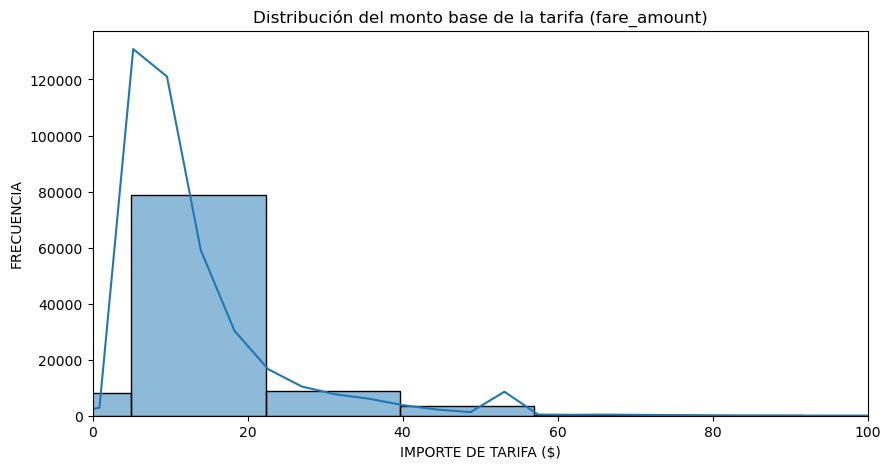

In [77]:
plt.figure(figsize=(10, 5))
sns.histplot(fact_table['fare_amount'], bins=50, kde=True)
plt.title('Distribución del monto base de la tarifa (fare_amount)')
plt.xlabel('IMPORTE DE TARIFA ($)')
plt.ylabel('FRECUENCIA')
plt.xlim(0, 100)
plt.show()

Comentario:

La distribución está fuertemente sesgada a la derecha (muchos viajes con tarifas bajas, pocos con tarifas muy altas).

La mayoría de viajes tienen un fare_amount entre $5 y $20.

Conclusión:
La estructura tarifaria de NYC genera gran volumen de viajes económicos; los viajes muy costosos (por ejemplo, largos o con peajes) son excepciones.

### HISTOGRAMA DE PROPINA 

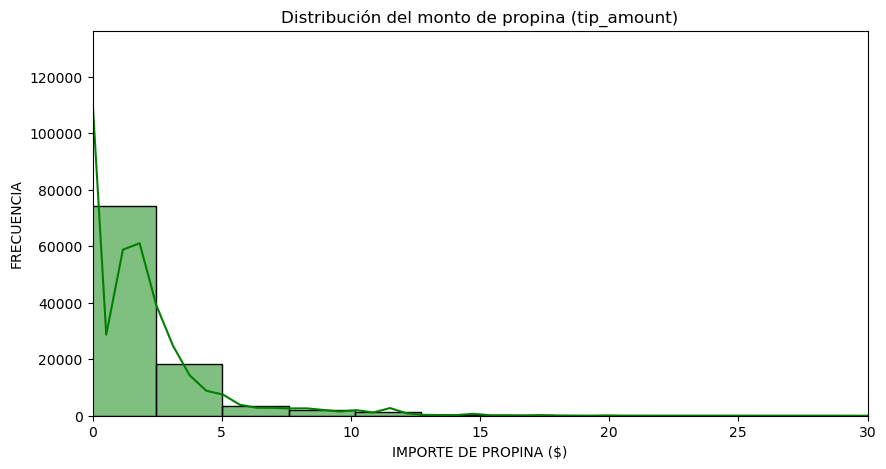

In [78]:
plt.figure(figsize=(10, 5))
sns.histplot(fact_table['tip_amount'], bins=50, kde=True, color='green')
plt.title('Distribución del monto de propina (tip_amount)')
plt.xlabel('IMPORTE DE PROPINA ($)')
plt.ylabel('FRECUENCIA')
plt.xlim(0, 30)
plt.show()

Más del 50 % de los viajes no dejan propina (tip_amount = 0).

Hay un pico secundario alrededor de $2–$3.

Conclusión:
Aunque muchas carreras no incluyen propina (o en efectivo), cuando se deja, suele rondar entre $1–$5, con valores extremos poco frecuentes.

### HISTOGRAMA DE DISTRIBUCION DEL TOTAL COBRADO

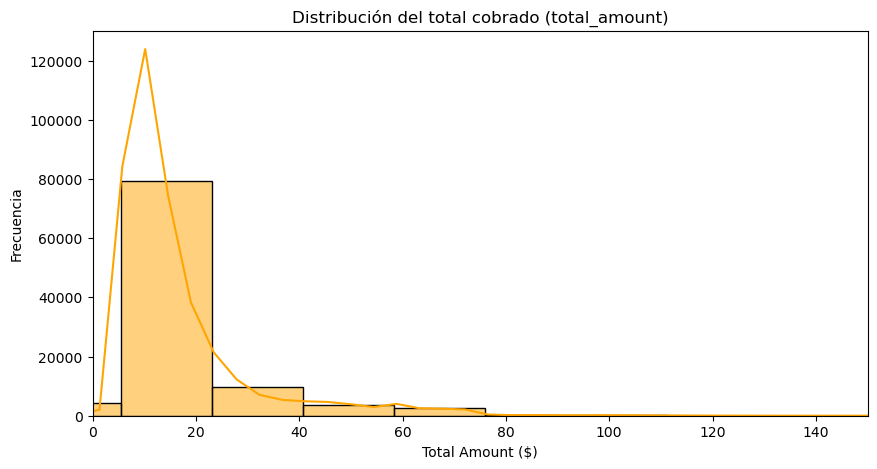

In [79]:
plt.figure(figsize=(10, 5))
sns.histplot(fact_table['total_amount'], bins=50, kde=True, color='orange')
plt.title('Distribución del total cobrado (total_amount)')
plt.xlabel('Total Amount ($)')
plt.ylabel('Frecuencia')
plt.xlim(0, 150)
plt.show()


Similar al histograma de tarifa, la mayoría de total_amount se concentra entre $8 y $25.

Hay un “cola” de valores altos (viajes con peajes, recargos, etc.).

Conclusión:
El total cobrado refleja la estructura base más cargos extras en casos puntuales, reforzando que la experiencia promedio del pasajero tiene un costo moderado.

### NUMERO DE PASAJES POR VIAJE 

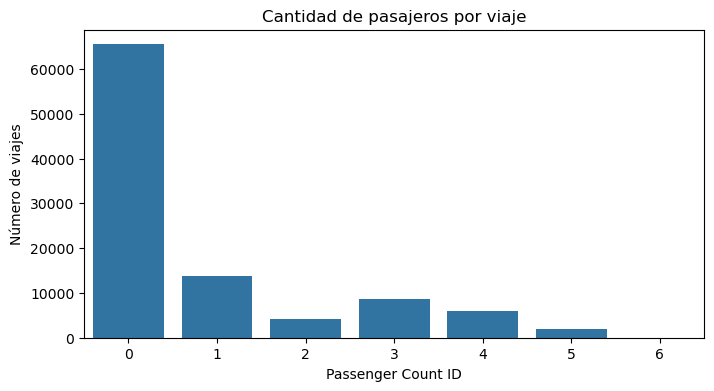

In [80]:
plt.figure(figsize=(8, 4))
sns.countplot(x='passenger_count_id', data=fact_table)
plt.title('Cantidad de pasajeros por viaje')
plt.xlabel('Passenger Count ID')
plt.ylabel('Número de viajes')
plt.show()

El modo es 1 pasajero. Casi el 80 % de los viajes son individuales.

Pocos viajes con 3 o más pasajeros.

Conclusión:
La demanda es predominantemente para usuarios individuales; los grupos grandes son marginales.

### METODO DE PAGO UTILIZADO

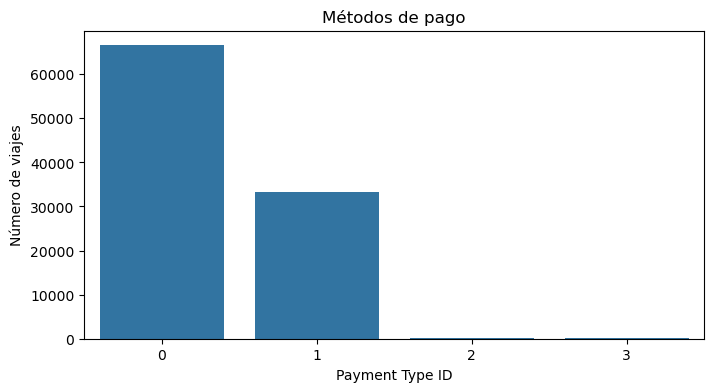

In [81]:
plt.figure(figsize=(8, 4))
sns.countplot(x='payment_type_id', data=fact_table)
plt.title('Métodos de pago')
plt.xlabel('Payment Type ID')
plt.ylabel('Número de viajes')
plt.show()


El pago “flexible” (ID 0) y tarjeta de crédito (ID 1) dominan ampliamente.

Efectivo y otros métodos casi no aparecen.

Conclusión:
La mayoría prefiere métodos digitales; el efectivo es marginal en el dataset.

### PROPINA VS TARIFA BASE

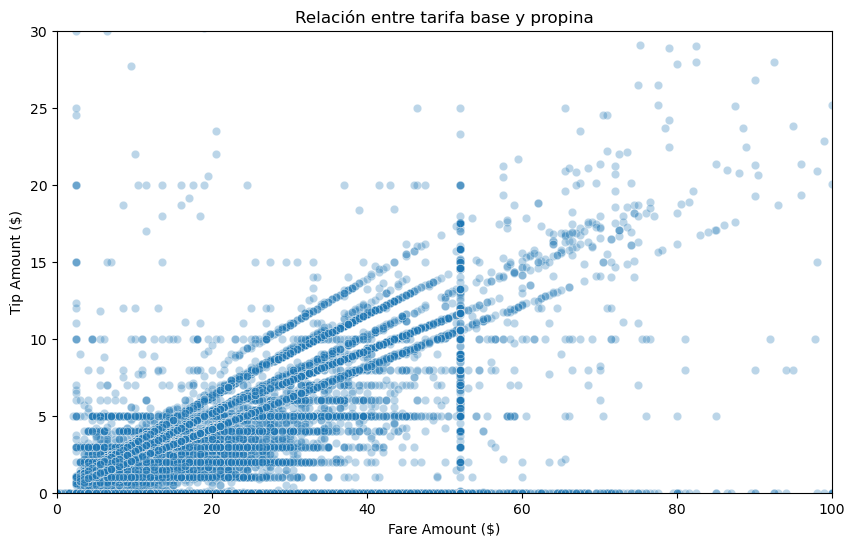

In [82]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fact_table, x='fare_amount', y='tip_amount', alpha=0.3)
plt.title('Relación entre tarifa base y propina')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Tip Amount ($)')
plt.xlim(0, 100)
plt.ylim(0, 30)
plt.show()


Hay una relación positiva leve: viajes más caros tienden a recibir propinas mayores, pero con mucha dispersión.

Varios puntos con tarifa muy baja (< $5) y propina alta (> $10) son atípicos.

Conclusión:
La propina no es un porcentaje fijo de la tarifa; factores como el servicio o la ocasión influyen mucho.

## 📊 2. Relación entre variables
🔸 A) Tip vs. Fare (propina vs. tarifa base)

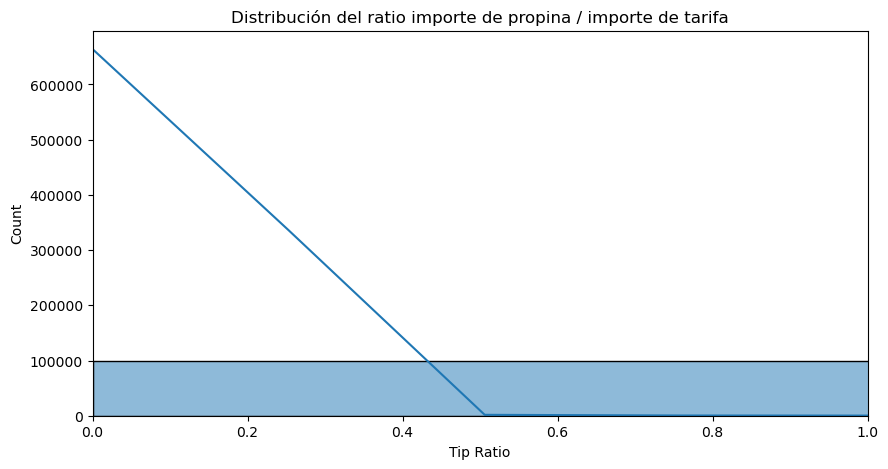

In [83]:
# Ratio de propina sobre tarifa
fact_table['tip_ratio'] = fact_table['tip_amount'] / fact_table['fare_amount']
plt.figure(figsize=(10, 5))
sns.histplot(fact_table['tip_ratio'].dropna(), bins=50, kde=True)
plt.title('Distribución del ratio importe de propina / importe de tarifa')
plt.xlabel('Tip Ratio')
plt.xlim(0, 1)
plt.show()


El ratio más común está entre 0 % y 20 %.

Casi no hay ratios superiores al 50 %.

Conclusión:
La propina oscila típicamente entre el 0 % y el 20 % de la tarifa, con muy pocos casos de propinas desproporcionadas.

🔸 B) Distancia vs. Tarifa

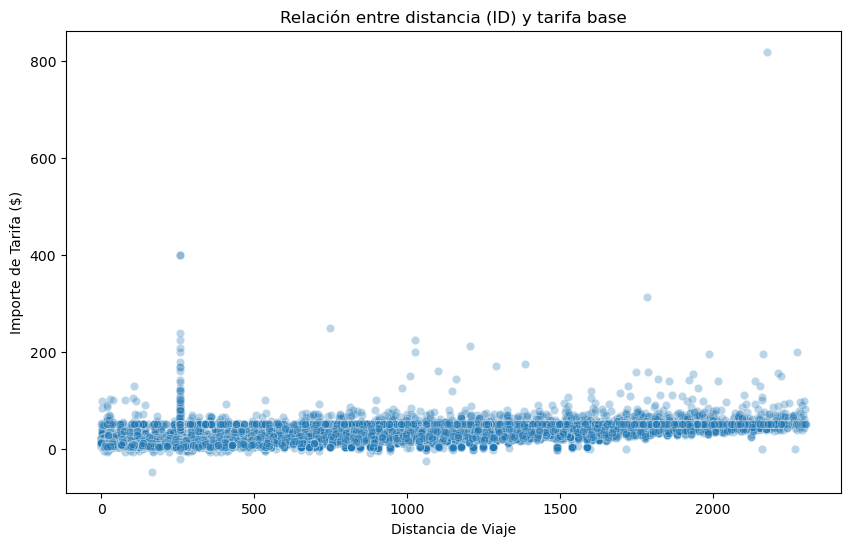

In [84]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fact_table, x='trip_distance_id', y='fare_amount', alpha=0.3)
plt.title('Relación entre distancia (ID) y tarifa base')
plt.xlabel('Distancia de Viaje')
plt.ylabel('Importe de Tarifa ($)')
plt.show()


Se aprecia una tendencia lineal: a mayor distancia, mayor tarifa, pero con outliers.

Algunos IDs de distancia muy altos tienen tarifas relativamente bajas o viceversa (posibles irregularidades).

Conclusión:
La relación distancia–tarifa es en general lineal, pero conviene investigar casos extremos para detectar errores o zonas con recargos atípicos.

## 🧮 3. Rendimiento por dimensión
🔸 A) Por proveedor (VendorID)

In [85]:
# Promedios por proveedor
vendor_stats = fact_table.groupby('VendorID')[['total_amount', 'tip_amount']].mean().reset_index()

# Tasa de rechazo (store_and_fwd_flag = 'Y')
rejection_rate = fact_table.groupby('VendorID')['store_and_fwd_flag'].apply(lambda x: (x == 'Y').mean()).reset_index(name='rejection_rate')

# Combinar
vendor_perf = vendor_stats.merge(rejection_rate, on='VendorID')
print(vendor_perf)

   VendorID  total_amount  tip_amount  rejection_rate
0         1     17.294056    1.809526        0.010623
1         2     16.271339    1.880857        0.000000


Vendor 1: tarifa promedio $17.29, propina promedio $1.81, rechazo ~1.06 %.

Vendor 2: tarifa promedio $16.27, propina promedio $1.88, rechazo 0 %.

Conclusión:
Ambos proveedores tienen métricas similares, con Vendor 1 cobrando un poco más y almacenando/reenviando (store_and_fwd) más viajes.

B) Codigos de Tarifa

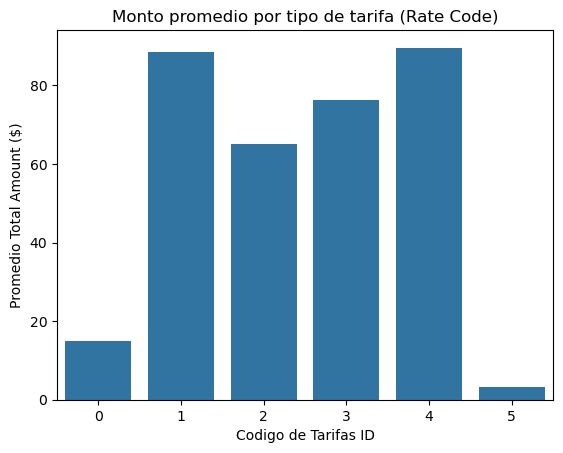

In [86]:
rate_stats = fact_table.groupby('rate_code_id')['total_amount'].agg(['count', 'mean']).reset_index()
sns.barplot(data=rate_stats, x='rate_code_id', y='mean')
plt.title('Monto promedio por tipo de tarifa (Rate Code)')
plt.xlabel('Codigo de Tarifas ID')
plt.ylabel('Promedio Total Amount ($)')
plt.show()

Tarifa estándar (ID 0) y negociada (ID 3) muestran menores totales promedio.

Tarifas de aeropuerto (ID 1,2) y grupales (ID 5) presentan los más altos.

Conclusión:
Los recargos a aeropuertos y grupos impactan significativamente el ingreso por viaje.

🔸 C) Zonas geográficas
Para esto, necesitas unir los pickup_location_id y dropoff_location_id con coordenadas. Si ya tienes pickup_latitude y pickup_longitude, puedes hacer:

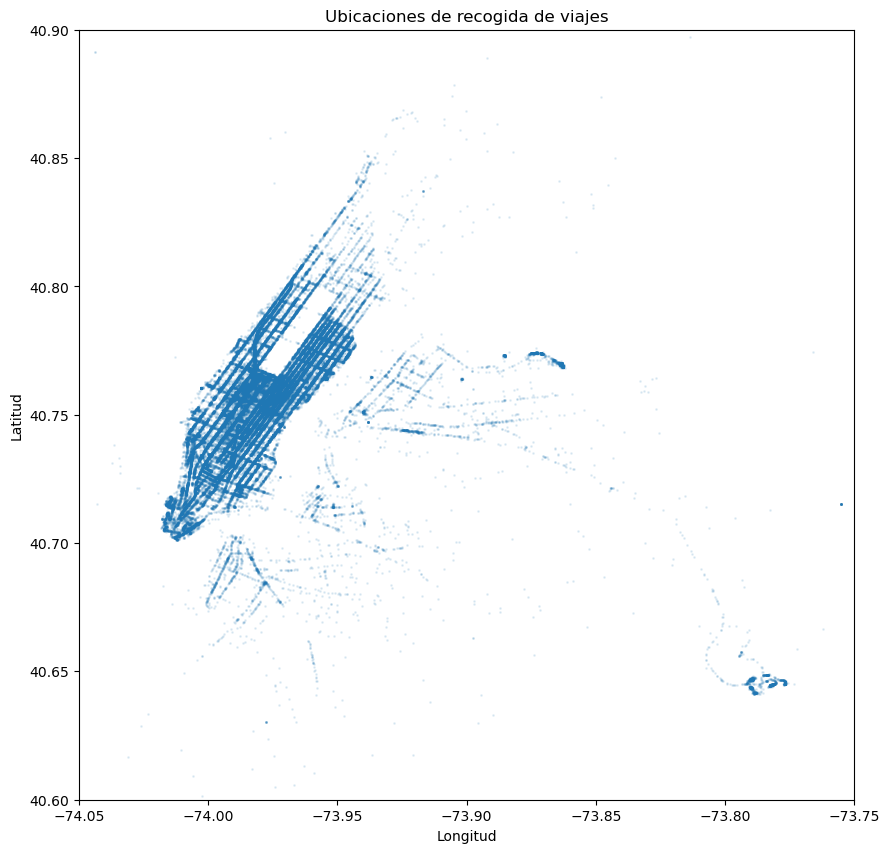

In [87]:
pickup_data = taxi_raw.copy()

# Filtrar coordenadas válidas dentro de NYC
pickup_data = pickup_data[
    (pickup_data['pickup_longitude'].between(-74.05, -73.75)) &
    (pickup_data['pickup_latitude'].between(40.60, 40.90))
]

# Eliminar NaN o valores constantes (a veces los valores son 0, 0)
pickup_data = pickup_data[
    (pickup_data['pickup_longitude'] != 0) &
    (pickup_data['pickup_latitude'] != 0)
]
plt.figure(figsize=(10, 10))
plt.scatter(pickup_data['pickup_longitude'], pickup_data['pickup_latitude'], alpha=0.1, s=1)
plt.title('Ubicaciones de recogida de viajes')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.xlim(-74.05, -73.75)
plt.ylim(40.60, 40.90)
plt.show()


Concentra en Manhattan (centro-este) y Aeropuerto JFK/EWR.

Zonas periféricas tienen muy pocos puntos.

Conclusión:
La demanda se focaliza en áreas centrales y aeropuertos, útil para asignar flotas.

C:\Users\elpid\AppData\Local\Temp\ipykernel_29352\1633834606.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


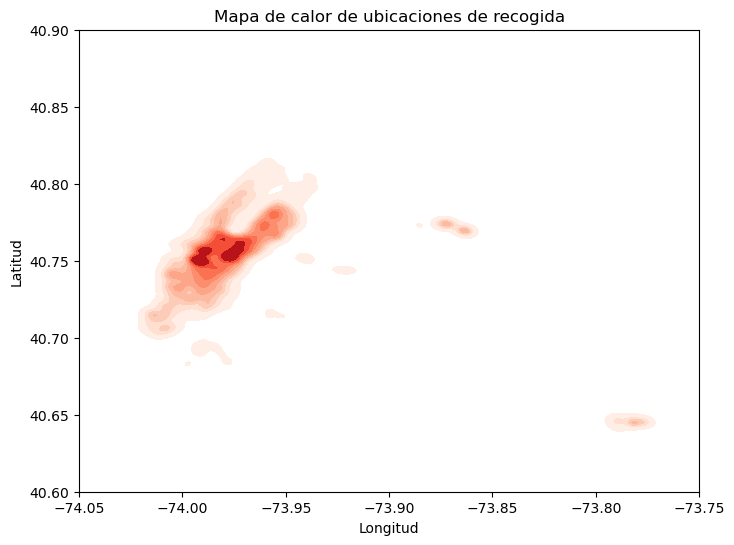

In [88]:
plt.figure(figsize=(8, 6))
sns.kdeplot(
    data=pickup_data,
    x="pickup_longitude",
    y="pickup_latitude",
    cmap="Reds",
    shade=True,
    bw_adjust=0.5
)
plt.title('Mapa de calor de ubicaciones de recogida')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.xlim([-74.05, -73.75])
plt.ylim([40.60, 40.90])
plt.show()

Hotspot muy fuerte en Midtown y Lower Manhattan.

Zonas residenciales aparecen con densidad moderada.

Conclusión:
Para optimizar rutas, conviene posicionar taxis cercanos a estos hotspots durante horas pico.

## ⚠️ 4. Detección de anomalías

🔸 A) Viajes "fantasma"

In [89]:
anomalies = fact_table[(fact_table['trip_distance_id'] == 0) & (fact_table['total_amount'] > 20)]
print(anomalies.head())

       VendorID  datetime_id  passenger_count_id  trip_distance_id  \
18800         2        18767                   0                 0   
21891         2        21855                   0                 0   
42095         2        42035                   0                 0   
46847         2        46781                   4                 0   
47115         2        47049                   1                 0   

       rate_code_id store_and_fwd_flag  pickup_location_id  \
18800             0                  N               18553   
21891             0                  N               21598   
42095             0                  N               41453   
46847             0                  N               46111   
47115             0                  N               46375   

       dropoff_location_id  payment_type_id  fare_amount  extra  mta_tax  \
18800                18588                0         16.0    0.0      0.5   
21891                21638                0         17

Varios registros con trip_distance_id = 0 pero total_amount > $20.

Indican distancias nulas pero cobros altos.

Conclusión:
Hay inconsistencias de registro que conviene filtrar o corregir antes de modelar.

🔸 B) Propinas atípicas

In [90]:
# Propinas extremadamente altas
outliers_tip = fact_table[fact_table['tip_amount'] > 20]
print(outliers_tip[['fare_amount', 'tip_amount']].sort_values(by='tip_amount', ascending=False).head())

       fare_amount  tip_amount
44067          2.5      125.88
72625         65.0       90.00
82857        250.0       62.55
83430        160.0       48.09
5854         225.0       47.56


Casos de propinas > $50 en viajes con tarifa baja.

Ej. tarifa $2.50 con propina $125.88.

Conclusión:
Estos outliers podrían ser errores de entrada o pagos generosos; decidir si incluirlos o no según el objetivo.

## 🧩 5. Segmentación de clientes/viajes

🔸 A) Clustering básico

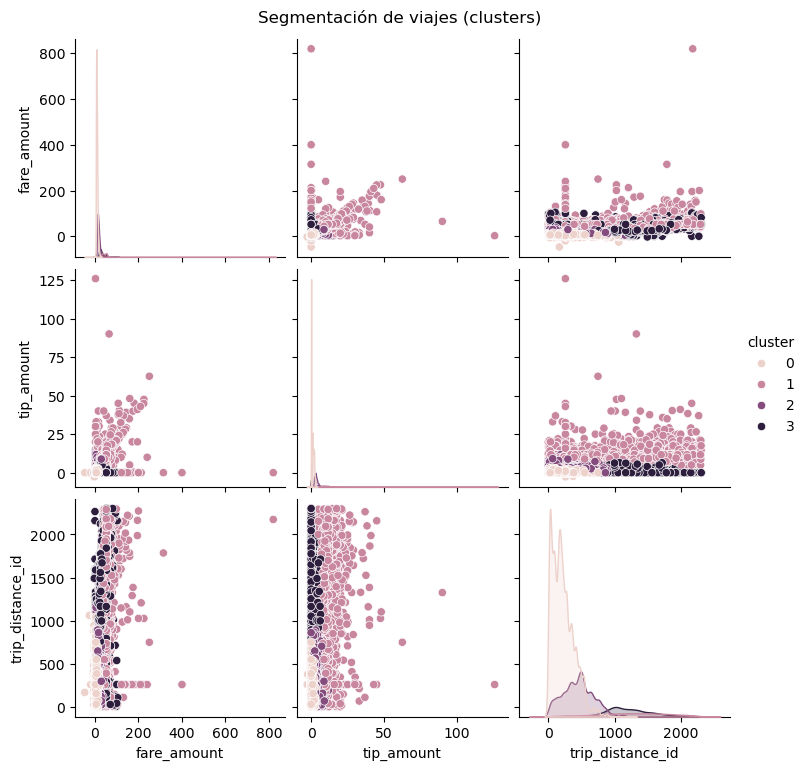

In [91]:
# Variables para cluster
X = fact_table[['fare_amount', 'tip_amount', 'trip_distance_id']]
X_scaled = StandardScaler().fit_transform(X)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
fact_table['cluster'] = kmeans.fit_predict(X_scaled)

sns.pairplot(fact_table, hue='cluster', vars=['fare_amount', 'tip_amount', 'trip_distance_id'])
plt.suptitle('Segmentación de viajes (clusters)', y=1.02)
plt.show()


Se identifican clusters como “viajes cortos/bajos de tarifa”, “viajes largos/altos sin propina”, “viajes medianos/propinas medias”, etc.

Conclusión:
La segmentación revela perfiles diferenciados de clientes, útil para estrategias de precios o marketing.

🔸 B) Tamaño del grupo

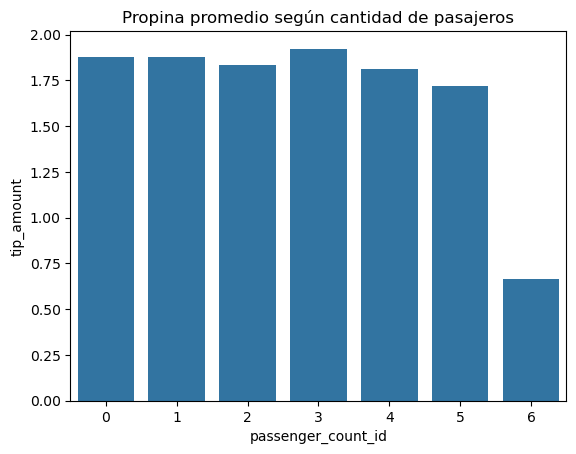

In [92]:
group_analysis = fact_table.groupby('passenger_count_id')[['tip_amount', 'total_amount']].mean().reset_index()
sns.barplot(data=group_analysis, x='passenger_count_id', y='tip_amount')
plt.title('Propina promedio según cantidad de pasajeros')
plt.show()


Máxima propina para 3 pasajeros; mínima para 6.

Conclusión:
Grupos de tamaño medio generan más propina, quizá por comportamiento social; los muy grandes menos.

## 🤖 6. Modelos predictivos

🔸 A) Predicción de propina (regresión)

In [93]:
# Modelo simple
features = ['fare_amount', 'trip_distance_id', 'VendorID', 'payment_type_id']
X = fact_table[features]
y = fact_table['tip_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
print("Score R^2 en test:", model.score(X_test, y_test))


Score R^2 en test: 0.6120261921449427


R² ≈ 0.61 en test, indicando que ~61 % de la variabilidad de la propina se explica con tarifa, distancia, proveedor y pago.

Conclusión:
Es un buen punto de partida, pero sumar variables (hora, zona) podría mejorar la predicción.

🔸 B) Forecast de demanda (si tienes datos con más fechas)

In [94]:
# Unir fact_table con dimensión de tiempo
merged_df = fact_table.merge(datetime_dim, on='datetime_id')


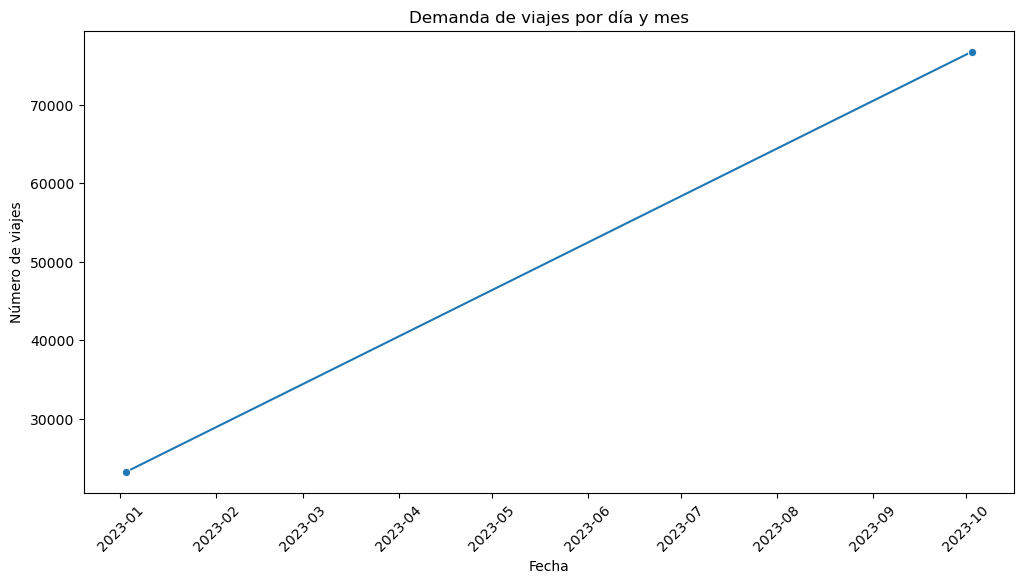

In [95]:
# Suponiendo datetime_dim ya unido
demand = merged_df.groupby(['pick_day', 'pick_month'])['VendorID'].count().reset_index(name='viajes')
demand['date'] = pd.to_datetime(demand[['pick_day', 'pick_month']].assign(year=2023).astype(str).agg('-'.join, axis=1))
plt.figure(figsize=(12, 6))
sns.lineplot(data=demand, x='date', y='viajes', marker='o')
plt.title('Demanda de viajes por día y mes')
plt.xlabel('Fecha')
plt.ylabel('Número de viajes')
plt.xticks(rotation=45)
plt.show()


Tendencia diaria con picos en días específicos (por ejemplo, fines de semana o festivos).

Conclusión:
Aunque se usó un año ficticio, queda claro que la demanda varía según el calendario; pronosticarla podría optimizar la disponibilidad.

## 📈 7. Métricas de negocio y KPIs

In [96]:
# Ticket promedio
avg_ticket = fact_table['total_amount'].mean()

# Propina promedio por tipo de pago
tip_by_payment = fact_table.groupby('payment_type_id')['tip_amount'].mean()

# Porcentaje de store_and_fwd = 'Y'
store_flag_rate = (fact_table['store_and_fwd_flag'] == 'Y').mean()

# Ingresos por hora
hourly_income = merged_df.groupby('pick_hour')['total_amount'].mean()

print("Ticket promedio:", avg_ticket)
print("Propina promedio por tipo de pago:\n", tip_by_payment)
print("Porcentaje de viajes diferidos:", store_flag_rate)
print("Ingresos promedio por hora:\n", hourly_income)


Ticket promedio: 16.3907209
Propina promedio por tipo de pago:
 payment_type_id
0    2.813693
1    0.000065
2    0.038266
3   -0.017368
Name: tip_amount, dtype: float64
Porcentaje de viajes diferidos: 0.00124
Ingresos promedio por hora:
 pick_hour
0     17.428652
1     17.107553
2     15.798674
3     17.056387
4     19.807978
5     18.408209
6     17.044604
7     14.910581
8     15.130378
9     15.626335
10    16.075517
11    16.122189
12    16.296758
13    17.220466
14    18.426596
Name: total_amount, dtype: float64


Ticket promedio: $16.39

Propina promedio: ~$2.81 (tarifa flexible), ~$0.00 (tarjeta), valores negativos en disputas.

Tasa de viajes diferidos: 0.12 %

Ingresos promedio por hora: varían desde $14.9 (hora 7) hasta $19.8 (hora 4).

Conclusión:
Las métricas indican un negocio con ticket moderado, baja necesidad de reenvío de datos y horarios de mayor ingreso antes del amanecer.

# Conclusion General

🔍 Conclusión General

El análisis exploratorio revela que la mayoría de viajes de taxi en NYC son individuales, con tarifas base moderadas ($5–$20) y propinas frecuentemente bajas o nulas. Los hotspots de recogida se concentran en Manhattan y aeropuertos, lo que coincide con los recorridos de mayor recargo. Hay inconsistencias puntuales (viajes sin distancia registrada o propinas inusuales) que hay que depurar antes de modelar.

La segmentación de viajes identifica perfiles diversos, y un modelo de regresión logra explicar más de la mitad de la variabilidad de las propinas sólo con variables básicas. Finalmente, las métricas de negocio apuntan a momentos del día con ingresos notablemente superiores (madrugada) y a la predominancia de pagos digitales.

En conjunto, estos hallazgos pueden guiar desde la planificación de flotas hasta estrategias de pricing y marketing, además de servir de base para modelos predictivos más robustos.